数据保存路径: C:\Users\25834\Desktop\PA\data\3.5GHz\20250919\
迭代次数: 4

载入原始信号数据...
原始信号载入完成，长度: 491520
\n=== 开始DPD迭代循环处理 ===
将测试指定模型: ['GMP']

=== 开始测试模型 1/1: GMP ===
\n--- 第 0 次迭代 ---
信号发生器发射原始信号...
频谱仪测量PA输出...
GMP第0次ACLR结果:
  载波功率: 0.821609 dBm
  邻道: 低相对: -29.428 dBc, 高相对: -29.1042 dBc
  次邻道: 低相对: -44.447 dBc, 高相对: -45.6645 dBc
第0次PA输出数据已保存，共10000个点
执行扫频分析...
\n执行第1次DPD处理...
bias：158
bias：4
bias：0
bias：0


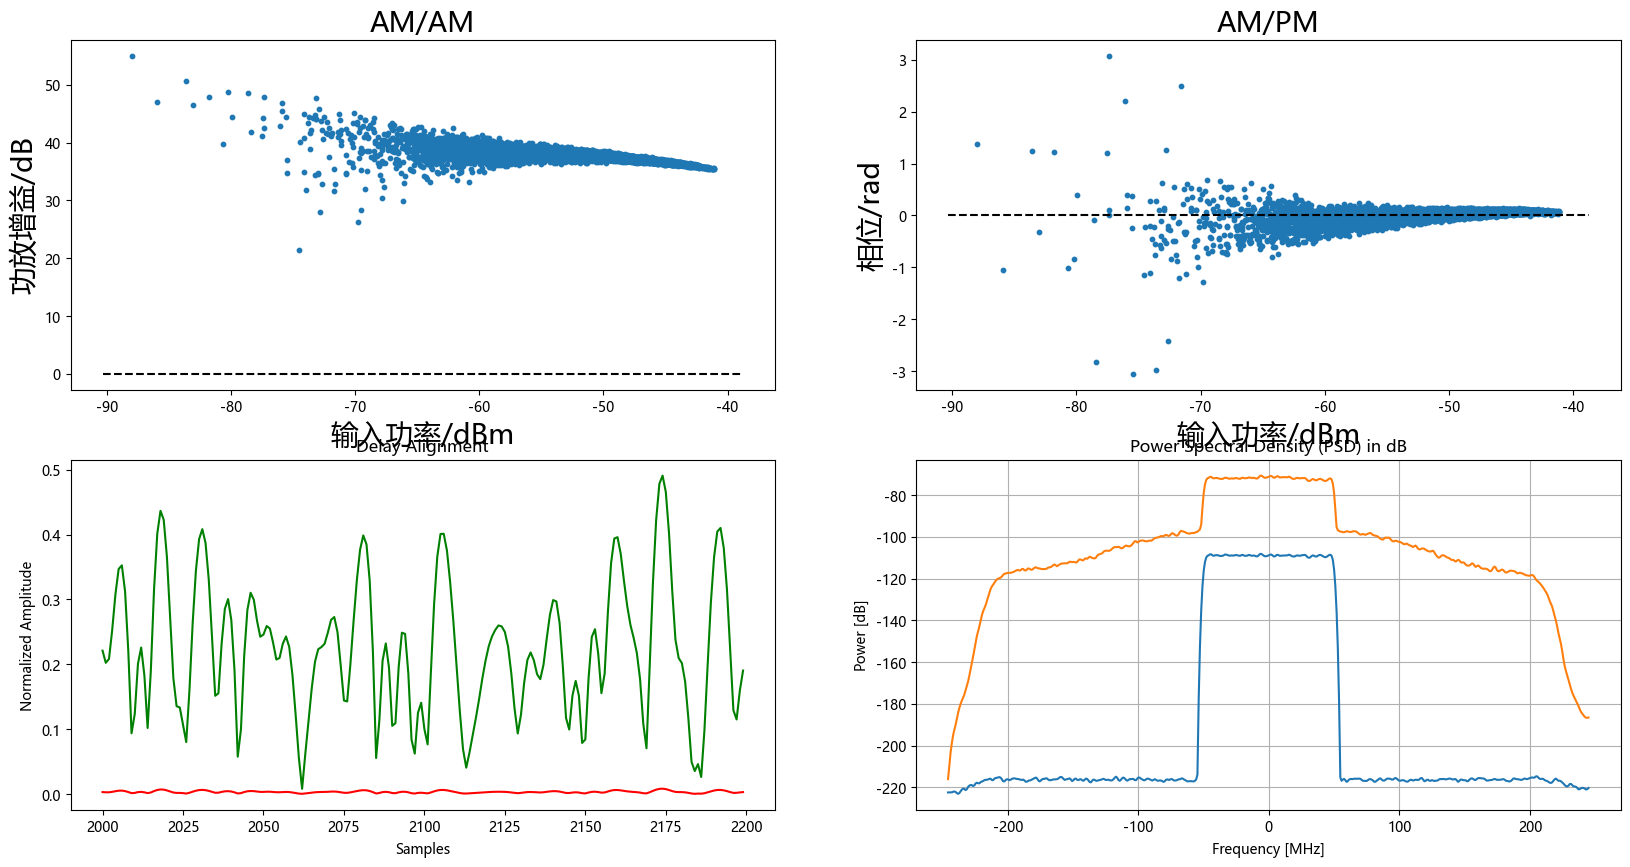

数据对齐偏移: 158
GMP: M:7 K:5 L:2
参数动态范围: 19.7147dB
NMSE: -38.1665dB
PAPR_in: 8.0120dB, PAPR_out: 6.4530dB, PAPR_dpd: 10.2618dB
C:/Users/25834/Desktop/PA/data/3.5GHz/20250919/ILA_GMP_7_5_2_dpd_0.txt
DPD信号已保存到: C:/Users/25834/Desktop/PA/data/3.5GHz/20250919/ILA_GMP_7_5_2_dpd_0.txt
\n--- 第 1 次迭代 ---
频谱仪测量PA输出...
GMP第1次ACLR结果:
  载波功率: 0.767005 dBm
  邻道: 低相对: -40.3118 dBc, 高相对: -38.1461 dBc
  次邻道: 低相对: -48.5514 dBc, 高相对: -49.3463 dBc
第1次PA输出数据已保存，共10000个点
执行扫频分析...
\n执行第2次DPD处理...
bias：157
bias：6
bias：0
bias：0


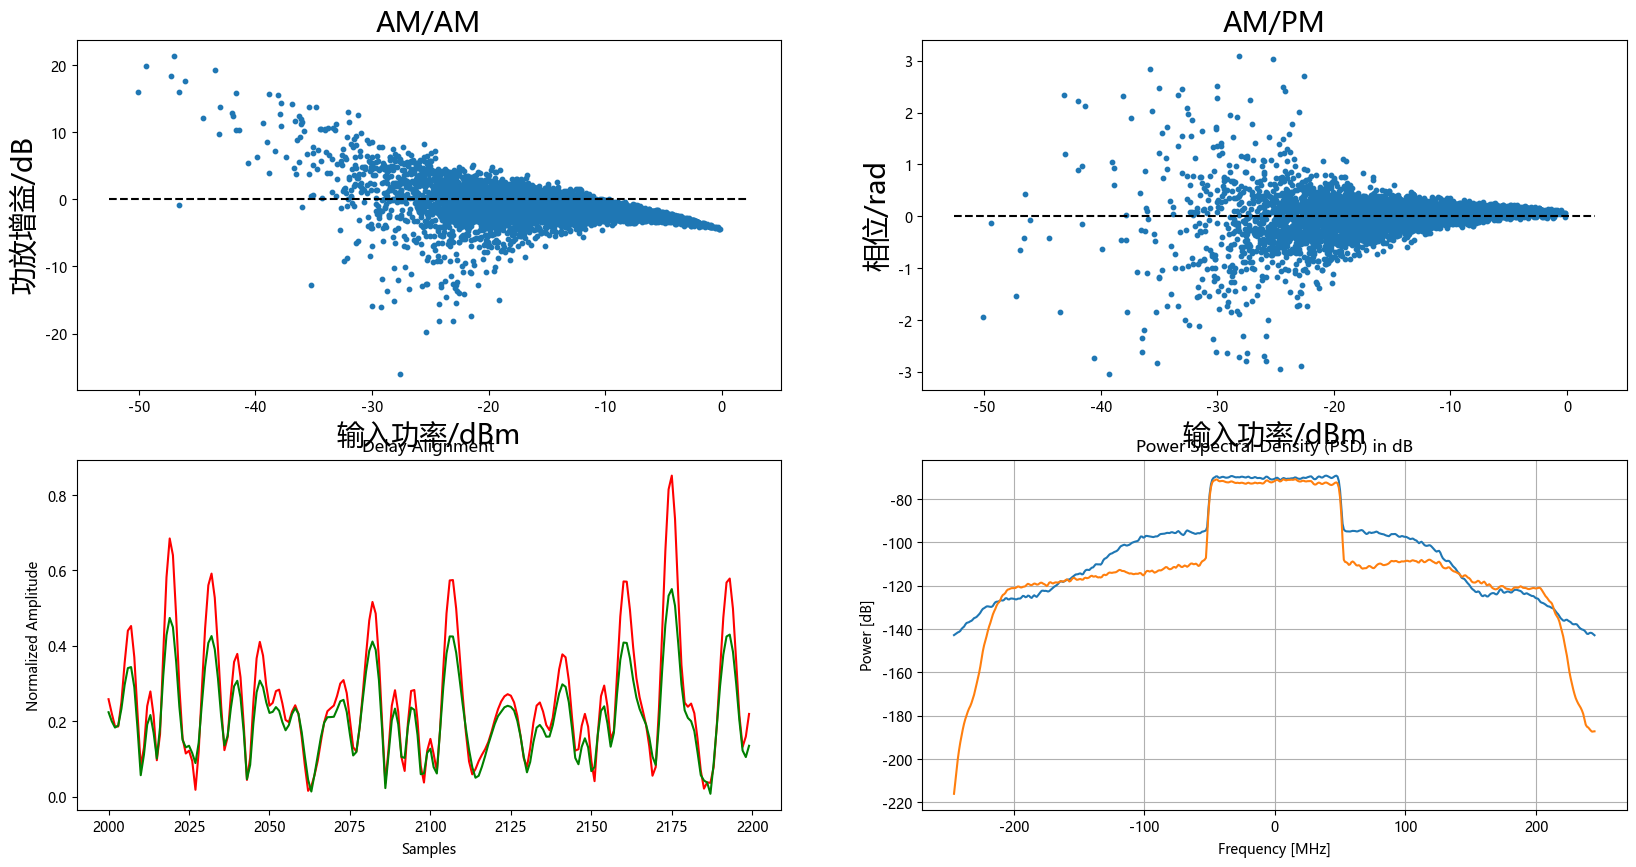

数据对齐偏移: 157
GMP: M:7 K:5 L:2
参数动态范围: 21.7920dB
NMSE: -38.4618dB
PAPR_in: 10.0491dB, PAPR_out: 7.6825dB, PAPR_dpd: 10.9539dB
C:/Users/25834/Desktop/PA/data/3.5GHz/20250919/ILA_GMP_7_5_2_dpd_1.txt
DPD信号已保存到: C:/Users/25834/Desktop/PA/data/3.5GHz/20250919/ILA_GMP_7_5_2_dpd_1.txt
\n--- 第 2 次迭代 ---
频谱仪测量PA输出...
GMP第2次ACLR结果:
  载波功率: 0.745866 dBm
  邻道: 低相对: -51.0921 dBc, 高相对: -46.1945 dBc
  次邻道: 低相对: -50.5554 dBc, 高相对: -49.2906 dBc
第2次PA输出数据已保存，共10000个点
执行扫频分析...
\n执行第3次DPD处理...
bias：156
bias：5
bias：0
bias：0


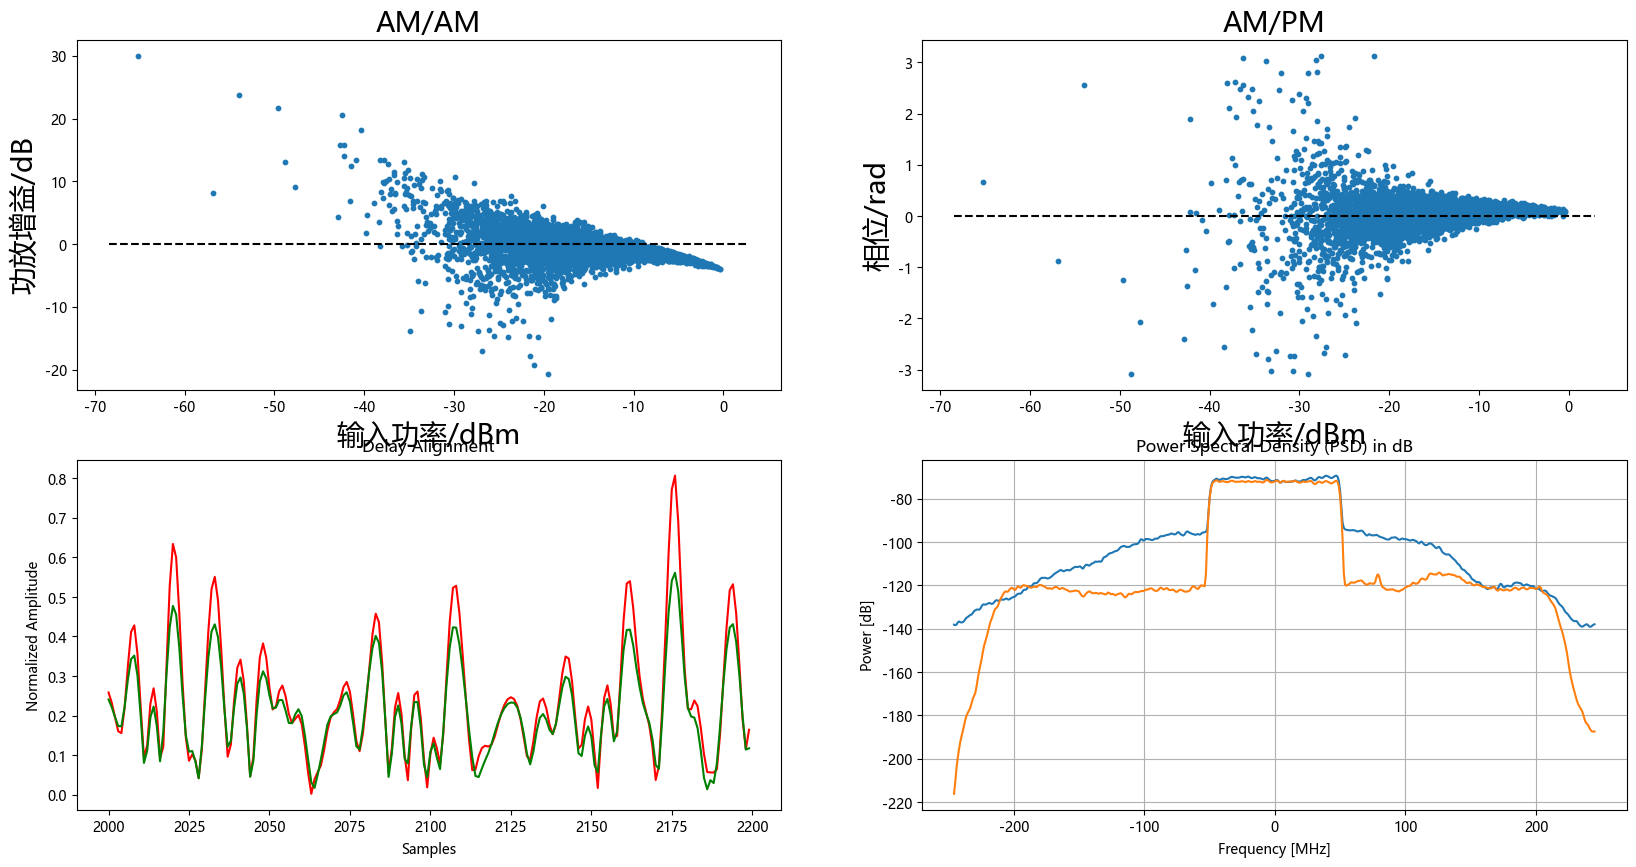

数据对齐偏移: 156
GMP: M:7 K:5 L:2
参数动态范围: 21.9285dB
NMSE: -38.9297dB
PAPR_in: 10.5047dB, PAPR_out: 7.9117dB, PAPR_dpd: 11.0235dB
C:/Users/25834/Desktop/PA/data/3.5GHz/20250919/ILA_GMP_7_5_2_dpd_2.txt
DPD信号已保存到: C:/Users/25834/Desktop/PA/data/3.5GHz/20250919/ILA_GMP_7_5_2_dpd_2.txt
\n--- 第 3 次迭代 ---
频谱仪测量PA输出...
GMP第3次ACLR结果:
  载波功率: 0.836925 dBm
  邻道: 低相对: -52.7865 dBc, 高相对: -49.3094 dBc
  次邻道: 低相对: -53.0567 dBc, 高相对: -50.3883 dBc
第3次PA输出数据已保存，共10000个点
执行扫频分析...


KeyboardInterrupt: 

In [4]:
%reset -f
# 导入必要的库
import pyvisa
import os
import struct
import time
import function
import sys
sys.path.append(os.path.abspath("code_ordered"))

import Tradition_function
from imp import reload
from function import *
from Tradition_function import *
reload(function)
reload(Tradition_function)
from RsSmw import *
import numpy as np
import matplotlib.pyplot as plt

# ============================
# 全局参数设置
# ============================

# 功能控制开关
ENABLE_SMW200A = 1               # 是否启用信号发生器
ENABLE_DPD_ITERATIONS = 1        # 是否执行DPD迭代循环
ENABLE_COMPARISON = 1            # 是否执行效果对比分析
ENABLE_SWEEP = 1                 # 是否执行扫频分析
ENABLE_ACPR = 1                  # 是否执行邻道功率测量
ENABLE_IQ_ANALYSIS = 1           # 是否执行IQ分析
ENABLE_SAVE_IQ = 1               # 是否保存IQ数据到文件
ENABLE_PLOT_PSD = 1              # 是否绘制功率谱密度图
ENABLE_UPLOAD_WAVEFORM = 1       # 是否上传波形文件到信号发生器

# 设备IP地址
SMW200A_IP = "192.168.1.201"
CEYEAR_IP = "192.168.1.202"

# 频率和功率设置
CENTER_FREQ = "3.5GHz"                     # 中心频率
POWER_LEVEL = "-10"                        # 功率电平(dBm)
SAMPLING_RATE = "491.52MHz"                # 采样率
SAMPLING_RATE_HZ = 491.52e6                # 采样率(Hz)
MEASUREMENT_TIME = "0.001"                 # 测量时间(秒)
IQ_RECORD_LENGTH = "10000"                # IQ记录长度

SWEEP_RANGE = "500MHz"                     # 扫频分析中扫频带宽
RBW_OCCUPIED = "1MHz"                      # 占用带宽测量RBW
VBW_OCCUPIED = "3MHz"                      # 占用带宽测量VBW

# 频谱仪RBW/VBW设置 (基于5G NR 100MHz信号)
RBW_ACLR = "100kHz"                        # ACLR测量RBW (满足3GPP要求)
VBW_ACLR = "300kHz"                        # ACLR测量VBW

# ACP测量参数
CARRIER_BW = "98.28MHz"                      # 载波带宽
ADJACENT_CH_OFFSET = "100MHz, 200MHz"        # 邻道偏移
ADJACENT_CH_BW = CARRIER_BW + ',' + CARRIER_BW  # 邻道带宽

# 数字预失真算法参数
model_name_all = ['M_MSA', 'I_MSA', 'MP', 'GMP', 'DDR', 'DVR']
MODEL_SELECTION_MODE = 0                   # 1=测试所有模型，0=只测试指定模型
DPD_MODEL_INDEX = 3                        # 选择GMP模型（当MODEL_SELECTION_MODE=0时使用）
DPD_ITERATIONS = 4                         # DPD迭代次数
mem_depth = 7                              # 记忆深度
K = 5                                      # 非线性阶数
L = 2                                      # GMP模型专用参数
isreversal = 1                             # 1=逆模型，0=正模型

# 文件路径和名称
date = time.strftime("%Y%m%d", time.localtime()) + "/"
LOCAL_DIR = f"C:\\Users\\25834\\Desktop\\PA\\data\\3.5GHz\\{date.replace('/', '')}\\"
data_ini_path = "C:/Users/25834/Desktop/PA/data/"
data_path = "C:/Users/25834/Desktop/PA/data/3.5GHz/"
data_out_path = data_path + date

# 信号文件名
data_ini_name = "NR-FR1-TM3.1a_100MHz_491.52Msps_30kHz_FDD_8.113dB"


# R&S SMW200A波形文件设置
INST_PRESET_WV_FILE = "USER/zwh/NR-FR1-TM3.1a_100MHz_491.52Msps_30kHz_FDD_8.113dB.wv"
INST_WV_DIR = f"USER/zwh/{date.replace('/', '')}"

# 创建本地数据保存目录
os.makedirs(LOCAL_DIR, exist_ok=True)
os.makedirs(data_out_path, exist_ok=True)

print(f"数据保存路径: {LOCAL_DIR}")
print(f"迭代次数: {DPD_ITERATIONS}")

# ============================
# 载入原始信号数据
# ============================
print("\n载入原始信号数据...")
data_ini_IQ, _, _ = load_data(data_ini_path, data_ini_name)
initial_signal = data_ini_IQ[:, 0] + 1j*data_ini_IQ[:, 1]
print(f"原始信号载入完成，长度: {len(initial_signal)}")

# ============================
# DPD迭代循环处理
# ============================

if ENABLE_DPD_ITERATIONS:
    print("\\n=== 开始DPD迭代循环处理 ===")
    
    # 存储所有模型的结果
    all_models_results = {}
    
    # 确定要测试的模型列表
    if MODEL_SELECTION_MODE == 1:
        models_to_test = model_name_all  # 测试所有模型
        print(f"将测试所有模型: {models_to_test}")
    else:
        models_to_test = [model_name_all[DPD_MODEL_INDEX]]  # 只测试指定模型
        print(f"将测试指定模型: {models_to_test}")
    
    # 模型选择循环
    for model_idx, model_name in enumerate(models_to_test):
        print(f"\n=== 开始测试模型 {model_idx+1}/{len(models_to_test)}: {model_name} ===")
        
        # 存储当前模型每次迭代的结果
        aclr_results_history = []
        pa_output_history = []
        max_NMSE_history = []
        if model_idx == 0:
            current_signal = initial_signal  # 当前信号发生器要发射的信号
                
        for iteration in range(DPD_ITERATIONS + 1):  # 第0次是原始信号
            print(f"\\n--- 第 {iteration} 次迭代 ---")
            
            # ============================
            # 步骤1：配置信号发生器发射当前信号
            # ============================
            if ENABLE_SMW200A:
                if iteration == 0:
                    print("信号发生器发射原始信号...")
                    # 第0次：发射预设的原始信号
                    rm_SMW200 = pyvisa.ResourceManager()
                    usr_SMW200 = rm_SMW200.open_resource(f"TCPIP0::{SMW200A_IP}::inst0::INSTR")
                    usr_SMW200.set_visa_attribute(pyvisa.constants.VI_ATTR_TERMCHAR_EN, pyvisa.constants.VI_TRUE)
                    usr_SMW200.set_visa_attribute(pyvisa.constants.VI_ATTR_TERMCHAR, ord('\n'))
                    usr_SMW200.timeout = 30000
                    
                    usr_SMW200.write("OUTPut:STATe OFF")
                    usr_SMW200.write(f"FREQ {CENTER_FREQ}")
                    usr_SMW200.write(f"POW {POWER_LEVEL}")
                    usr_SMW200.write("SOURce1:BB:ARBitrary:TRIGger:OUTPut1:MODE RESTart")
                    usr_SMW200.write("OUTPut:USER1:DIRection OUTP")
                    usr_SMW200.write("OUTPut:USER1:SIGNal MARKA1")
                    usr_SMW200.write("OUTPut:USER4:DIRection OUTP")
                    usr_SMW200.write("OUTPut:USER4:SIGNal MARKA1")
                    
                    usr_SMW200.write(f'SOURce:BB:ARB:WAV:SELect "{INST_PRESET_WV_FILE}"')
                    usr_SMW200.write("SOURce:BB:ARB:STATe ON")
                    usr_SMW200.write("OUTPut:STATe ON")
                    
                    usr_SMW200.close()
                    rm_SMW200.close()
                else:
                    # 创建并上传DPD波形文件
                    RsSmw.assert_minimum_version('5.0.44')
                    smw = RsSmw(f'TCPIP0::{SMW200A_IP}::inst0::INSTR')
                    rm = pyvisa.ResourceManager()
                    usr_SMW200 = rm.open_resource(f"TCPIP0::{SMW200A_IP}::inst0::INSTR")
                    usr_SMW200.timeout = 30000
                    
                    usr_SMW200.write('OUTP:STAT OFF')
                    usr_SMW200.write(f'MMEM:MDIR "{INST_WV_DIR}"')
                    
                    # # 保存当前信号到文件
                    # current_signal_file = os.path.join(LOCAL_DIR, f'current_signal_iter_{iteration}.txt')
                    # current_signal_data = np.column_stack([current_signal.real, current_signal.imag])
                    # np.savetxt(current_signal_file, current_signal_data, fmt='%.8f')
                    if model_name == 'GMP':
                        dpd_path_wv = data_out_path + model_name+"_" + str(mem_depth) + "_"+ str(K) + "_"+ str(L) + "_dpd_"+ str(iteration) + ".wv"
                        INST_WV_FILE = f"{INST_WV_DIR}/ILA_{model_name}_{mem_depth}_{K}_{L}_dpd_{iteration}.wv"
                    else:
                        dpd_path_wv = data_out_path + model_name+"_" + str(mem_depth) + "_"+ str(K) + "_dpd_"+ str(iteration) + ".wv"
                        INST_WV_FILE = f"{INST_WV_DIR}/ILA_{model_name}_{mem_depth}_{K}_dpd_{iteration}.wv"
                    
                    # 创建波形文件
                    LOCAL_WV_FILE = os.path.join(LOCAL_DIR, dpd_path_wv)
                    # INST_WV_FILE = f"{INST_WV_DIR}/dpd_signal_iter_{iteration}.wv"
                    
                    smw.arb_files.create_waveform_file_from_samples(
                        current_signal.real, current_signal.imag, LOCAL_WV_FILE,
                        clock_freq=SAMPLING_RATE_HZ, auto_scale=True,
                        additional_tags=['MARKER LIST 1: 0:1;10:0'],
                        comment=f'DPD iteration {iteration}'
                    )
                    
                    # 上传波形文件
                    with open(LOCAL_WV_FILE, 'rb') as file:
                        file_content = file.read()
                    
                    data_len = len(file_content)
                    len_str = str(data_len)
                    header = f'#{len(len_str)}{len_str}'
                    
                    usr_SMW200.write_raw(f'MMEM:DATA "{INST_WV_FILE}",'.encode() + header.encode() + file_content)
                    usr_SMW200.write(f'SOURce:BB:ARB:WAV:SELect "{INST_WV_FILE}"')
                    usr_SMW200.write('SOURce:BB:ARB:STATe ON')
                    usr_SMW200.write('OUTP:STAT ON')
                
                    usr_SMW200.close()
                    rm.close()
            
            # ============================
            # 步骤2：频谱仪测量PA输出
            # ============================
            print("频谱仪测量PA输出...")
            rm_ceyear = pyvisa.ResourceManager()
            usr_ceyear = rm_ceyear.open_resource(f"TCPIP0::{CEYEAR_IP}::5025::SOCKET")
            usr_ceyear.set_visa_attribute(pyvisa.constants.VI_ATTR_TERMCHAR_EN, pyvisa.constants.VI_TRUE)
            usr_ceyear.set_visa_attribute(pyvisa.constants.VI_ATTR_TERMCHAR, ord('\n'))
            usr_ceyear.set_visa_attribute(pyvisa.constants.VI_ATTR_TMO_VALUE, 10000)
            
            # ACLR测量
            if ENABLE_ACPR:
                usr_ceyear.write(":CONFigure:ACPower")
                time.sleep(1)
                usr_ceyear.write(f":BAND {RBW_ACLR}")
                usr_ceyear.write(f":BAND:VID {VBW_ACLR}")
                usr_ceyear.write(":RAD:STAN NR5GFR1B100M")
                usr_ceyear.write(":TRAC1:ACP:TYPE AVERage")
                time.sleep(2)
                usr_ceyear.write(":FETC:ACP?")
                acp_results = usr_ceyear.read().strip().split(',')
                aclr_results_history.append(acp_results)
                
                print(f"{model_name}第{iteration}次ACLR结果:")
                print(f"  载波功率: {acp_results[0]} dBm")
                print(f"  邻道: 低相对: {acp_results[2]} dBc, 高相对: {acp_results[4]} dBc")
                print(f"  次邻道: 低相对: {acp_results[6]} dBc, 高相对: {acp_results[8]} dBc")
            
            
            # IQ数据采集
            if ENABLE_IQ_ANALYSIS:
                usr_ceyear.write(":INST BASIC")
                usr_ceyear.write(f":FREQ:CENT {CENTER_FREQ}")
                usr_ceyear.write("ROSC:SOUR E10")
                usr_ceyear.write("TRIG:SOUR EXT1")
                usr_ceyear.write(f'TRAC:IQ:SRAT {SAMPLING_RATE}')
                # usr_ceyear.write(f'SWE:TIME {MEASUREMENT_TIME}')
                usr_ceyear.write(f'TRAC:IQ:RLEN {IQ_RECORD_LENGTH}')
                usr_ceyear.write(':ADJ:LEV')
                time.sleep(5)
                
                usr_ceyear.write('INIT:IMM')
                usr_ceyear.clear()
                time.sleep(1)
                
                # 读取IQ数据
                usr_ceyear.timeout = 30000
                usr_ceyear.write(":FORM:DATA REAL,32")
                usr_ceyear.write(":TRAC:IQ:DATA?")
                
                usr_ceyear.set_visa_attribute(pyvisa.constants.VI_ATTR_TERMCHAR_EN, pyvisa.constants.VI_FALSE)
                
                # 读取二进制块头
                header = usr_ceyear.read_bytes(2)
                digit_count = header[1] - 48
                length_str = usr_ceyear.read_bytes(digit_count).decode('ascii')
                data_length = int(length_str)
                
                # 分块读取数据
                raw_data = bytearray()
                chunk_size = 1024 * 1024
                remaining = data_length
                
                while remaining > 0:
                    chunk = min(remaining, chunk_size)
                    raw_data.extend(usr_ceyear.read_bytes(chunk))
                    remaining -= chunk
                
                usr_ceyear.read_bytes(1)
                
                # 转换为浮点数数组
                float_count = len(raw_data) // 4
                iq_data_current = struct.unpack(f'{float_count}f', raw_data)
                usr_ceyear.set_visa_attribute(pyvisa.constants.VI_ATTR_TERMCHAR_EN, pyvisa.constants.VI_TRUE)
                
                # 转换为复数并保存
                pa_output_current = np.array([[iq_data_current[i], iq_data_current[i+1]] 
                                             for i in range(0, len(iq_data_current), 2)])
                pa_output_complex = pa_output_current[:, 0] + 1j*pa_output_current[:, 1]
                pa_output_history.append(pa_output_complex)
                
                # 保存PA输出数据
                if ENABLE_SAVE_IQ:
                    if model_name == 'GMP':
                        pa_output_file = data_out_path +"ILA_" + model_name+"_" + str(mem_depth) + "_"+ str(K) + "_"+ str(L) + "_dpd_out_"+ str(iteration) + ".txt"
                        
                    else:
                        pa_output_file = data_out_path +"ILA_"  + model_name+"_" + str(mem_depth) + "_"+ str(K) + "_dpd_out_"+ str(iteration) + ".txt"
                        
                    np.savetxt(pa_output_file, pa_output_current, fmt='%.8f')
                    print(f"第{iteration}次PA输出数据已保存，共{len(pa_output_complex)}个点")
                else:
                    print(f"第{iteration}次PA输出数据已采集，共{len(pa_output_complex)}个点（未保存）")
                
                usr_ceyear.write('INIT:CONT ON')
                # usr_ceyear.close()
                # rm_ceyear.close()
            

            # 配置扫频分析设置
            if ENABLE_SWEEP:
                print("执行扫频分析...")
                usr_ceyear.write(":INST SA")                     # 切换到频谱分析模式
                usr_ceyear.write(f":FREQ:CENT {CENTER_FREQ}")    # 设置中心频率
                usr_ceyear.write(f":FREQ:SPAN {SWEEP_RANGE}")    # 设置扫频范围
                
                # 设置RBW和VBW用于占用带宽测量
                # usr_ceyear.write(f":BAND {RBW_OCCUPIED}")    # 设置分辨带宽
                # usr_ceyear.write(f":BAND:VID {VBW_OCCUPIED}")    # 设置视频带宽
                
                time.sleep(1)
                
                # 配置6条曲线的循环显示逻辑
                # 首先确保所有曲线都是关闭的，只在需要时打开
                if model_idx == 0 and iteration == 0:
                    for i in range(1, 7):
                        usr_ceyear.write(f":TRAC{i}:DISP OFF")
                
                    usr_ceyear.write(":TRAC1:DISP ON")
                    usr_ceyear.write(":TRAC1:TYPE AVER")         # 曲线1设置为平均模式
                    usr_ceyear.write(":TRAC1:UPD ON")            # 开启曲线1更新
                    time.sleep(5)  # 等待平均完成
                    usr_ceyear.write(":TRAC1:UPD OFF")           # 固定曲线1（永久参考）
                    # print("曲线1已固定为原始PA输出（永久参考）")
                elif iteration == 0:
                    time.sleep(0.1)
                else:
                    # 确定当前模型的曲线显示范围
                    current_trace = model_idx + iteration % 5 + 1  # 当前模型的起始曲线位置                
                                
                    # 设置当前曲线进行测量
                    usr_ceyear.write(f":TRAC{current_trace}:DISP ON")
                    usr_ceyear.write(f":TRAC{current_trace}:TYPE AVER")  # 当前曲线设置为平均模式
                    usr_ceyear.write(f":TRAC{current_trace}:UPD ON")     # 开启当前曲线更新
                    # print(f"曲线{current_trace}正在测量{model_name}模型迭代{iteration}")
                    time.sleep(5)  # 等待当前曲线平均完成
                    usr_ceyear.write(f":TRAC{current_trace}:UPD OFF")     # 开启当前曲线更新
                    

            # ============================
            # 步骤3：DPD处理（除了最后一次）
            # ============================
            if iteration < DPD_ITERATIONS:
                print(f"\\n执行第{iteration+1}次DPD处理...")
                
                # 数据对齐
                pa_in_c, pa_out_c, bias, _ = alignment(current_signal, pa_output_complex, SAMPLING_RATE_HZ, 25, 1)
                print(f"数据对齐偏移: {bias}")
                
                # 归一化
                pa_in_norm = pa_in_c / np.max(np.abs(pa_in_c))
                pa_out_norm = pa_out_c / np.max(np.abs(pa_out_c))
                initial_norm = initial_signal / np.max(np.abs(initial_signal))
                
                # DPD输入信号扩展（基于原始信号）
                o_len = len(initial_norm)
                if model_name == 'GMP':
                    orig_complex = np.append(np.append(initial_norm[o_len-mem_depth-L:], initial_norm), 
                                           initial_norm[:L])
                    print(f'{model_name}: M:{mem_depth} K:{K} L:{L}')                    
                    dpd_path = data_out_path +"ILA_"  + model_name+"_" + str(mem_depth) + "_"+ str(K) + "_"+ str(L) + "_dpd_"+ str(iteration) + ".txt"
                    
                else:
                    orig_complex = np.append(initial_norm[o_len-mem_depth:], initial_norm)
                    print(f'{model_name}: M:{mem_depth} K:{K}')
                    dpd_path = data_out_path  +"ILA_" + model_name+"_" + str(mem_depth) + "_"+ str(K) + "_dpd_"+ str(iteration) + ".txt"
    
                
                # 根据模型进行DPD处理
                if model_name == 'M_MSA':
                    beta = [k/K for k in range(K+1)]
                    if isreversal == 1:
                        sam_input, sam_output, sam_xn = generate_data_for_mmsa(pa_out_norm, pa_in_norm, mem_depth)
                    else:
                        sam_input, sam_output, sam_xn = generate_data_for_mmsa(pa_in_norm, pa_out_norm, mem_depth)
                    
                    para = sort_and_compute_para_for_mmsa(sam_xn, sam_input, sam_output, K, beta)
                    y_fit = compute_u_for_mmsa(sam_xn, sam_input, K, para, beta)
                    Max_NMSE = cal_NMSE_np(sam_output, y_fit)
                    
                    sam_input, _, sam_xn = generate_data_for_mmsa(orig_complex, pa_out_norm, mem_depth)
                    dpd_signal = compute_u_for_mmsa(sam_xn, sam_input, K, para, beta)
                
                elif model_name == 'I_MSA':
                    beta = [k/K for k in range(K+1)]
                    if isreversal == 1:
                        sam_input, sam_output = generate_data_for_imsa(pa_out_norm, pa_in_norm, mem_depth)
                    else:
                        sam_input, sam_output = generate_data_for_imsa(pa_in_norm, pa_out_norm, mem_depth)
                    
                    para = sort_and_compute_para_for_imsa(sam_input, sam_output, K, beta)
                    y_fit, _ = compute_u_for_imsa(sam_input, K, para, beta)
                    Max_NMSE = cal_NMSE_np(sam_output, y_fit)
                    
                    sam_input, _ = generate_data_for_imsa(orig_complex, pa_out_norm, mem_depth)
                    dpd_signal, _ = compute_u_for_imsa(sam_input, K, para, beta)
                    
                elif model_name == 'MP':
                    if isreversal == 1:
                        sam_input, sam_output = generate_data_for_mp(pa_out_norm, pa_in_norm, mem_depth, K)
                        para, x_fit = compute_u_for_mp(sam_input, sam_output)
                        Max_NMSE = cal_NMSE_np(pa_in_norm[mem_depth:], x_fit)
                    else:
                        sam_input, sam_output = generate_data_for_mp(pa_in_norm, pa_out_norm, mem_depth, K)
                        para, x_fit = compute_u_for_mp(sam_input, sam_output)
                        Max_NMSE = cal_NMSE_np(pa_out_norm[mem_depth:], x_fit)
                    
                    x_array, _ = generate_data_for_mp(orig_complex, orig_complex, mem_depth, K)
                    dpd_signal = np.dot(x_array, para)
                    
                elif model_name == 'GMP':
                    if isreversal == 1:
                        sam_input, sam_output = generate_data_for_gmp(pa_out_norm, pa_in_norm, mem_depth, K, L)
                        para, x_fit = compute_u_for_gmp(sam_input, sam_output)
                        Max_NMSE = cal_NMSE_np(pa_in_norm[mem_depth+L:-L], x_fit)
                    else:
                        sam_input, sam_output = generate_data_for_gmp(pa_in_norm, pa_out_norm, mem_depth, K, L)
                        para, y_fit = compute_u_for_gmp(sam_input, sam_output)
                        Max_NMSE = cal_NMSE_np(pa_out_norm[mem_depth+L:-L], y_fit)
                    
                    x_array, _ = generate_data_for_gmp(orig_complex, orig_complex, mem_depth, K, L)
                    dpd_signal = np.dot(x_array, para)
                    
                elif model_name == 'DDR':
                    if isreversal == 1:
                        sam_input, sam_output = generate_data_for_ddr(pa_out_norm, pa_in_norm, mem_depth, K)
                        para, x_fit = compute_u_for_ddr(sam_input, sam_output)
                        Max_NMSE = cal_NMSE_np(pa_in_norm[mem_depth:], x_fit)
                    else:
                        sam_input, sam_output = generate_data_for_ddr(pa_in_norm, pa_out_norm, mem_depth, K)
                        para, x_fit = compute_u_for_ddr(sam_input, sam_output)
                        Max_NMSE = cal_NMSE_np(pa_out_norm[mem_depth:], x_fit)
                    
                    x_array, _ = generate_data_for_ddr(orig_complex, orig_complex, mem_depth, K)
                    dpd_signal = np.dot(x_array, para)
                    
                elif model_name == 'DVR':  # DVR
                    beta = [k/K for k in range(K+1)]
                    if isreversal == 1:
                        X_base, U = generate_data_for_dvr(pa_out_norm, pa_in_norm, mem_depth, beta)
                        para = np.dot(np.linalg.pinv(X_base), U)
                        x_fit = np.dot(X_base, para)
                        Max_NMSE = cal_NMSE_np(pa_in_norm[mem_depth:], x_fit)
                    else:
                        X_base, U = generate_data_for_dvr(pa_in_norm, pa_out_norm, mem_depth, beta)
                        para = np.dot(np.linalg.pinv(X_base), U)
                        x_fit = np.dot(X_base, para)
                        Max_NMSE = cal_NMSE_np(pa_out_norm[mem_depth:], x_fit)
                    
                    dpd_signal = compute_u_for_dvr(orig_complex, mem_depth, beta, para)
                
                max_NMSE_history.append(Max_NMSE)

                # 输出DPD处理结果
                print(f"参数动态范围: {20 * np.log10(np.abs(np.max(para)-np.min(para))):.4f}dB")
                print(f"NMSE: {np.array(Max_NMSE):.4f}dB")
                print(f"PAPR_in: {cal_PAPR(pa_in_norm):.4f}dB, PAPR_out: {cal_PAPR(pa_out_norm):.4f}dB, PAPR_dpd: {cal_PAPR(dpd_signal):.4f}dB")
                
                # 保存DPD信号
                # dpd_file_name = f"{model_name}_{mem_depth}_{K}_{L}_dpd_{iteration+1}.txt"
                # dpd_path = os.path.join(data_out_path, dpd_file_name)
                save_txt_func(dpd_signal, dpd_path)
                print(f"DPD信号已保存到: {dpd_path}")
                
                # 更新当前信号为下一次迭代的输入
                current_signal = dpd_signal         
                      

            usr_ceyear.close()
            rm_ceyear.close()

        # 保存当前模型的结果
        all_models_results[model_name] = {
            'aclr_history': aclr_results_history.copy(),
            'pa_output_history': pa_output_history.copy(),
            'max_NMSE_history': max_NMSE_history.copy(),
            'final_signal': current_signal.copy()
        }
        print(f"\\n模型 {model_name} 测试完成！")
        
    print("\\n所有模型DPD迭代循环完成！")
    

    
    # 打印所有模型的结果摘要
    print("\\n=== 所有模型结果摘要 ===")
    for model_name, results in all_models_results.items():
        if results['aclr_history']:
            final_aclr = results['aclr_history'][-1]
            print(f"{model_name}: 最终ACLR - 邻道低: {final_aclr[2]} dBc, 邻道高: {final_aclr[4]} dBc")

else:
    print("已跳过DPD迭代循环")


In [ ]:
# ============================
# 效果对比分析
# ============================

if ENABLE_COMPARISON and ENABLE_DPD_ITERATIONS:
    print("\\n=== 效果对比分析 ===")
    
    # # ACLR改善趋势分析
    # print("\\n=== ACLR迭代改善趋势 ===")
    # for i, acp_results in enumerate(aclr_results_history):
    #     print(f"第{i}次迭代 ACLR:")
    #     print(f"  载波功率: {acp_results[0]} dBm")
    #     print(f"  邻道: 低 {acp_results[2]} dBc, 高 {acp_results[4]} dBc")
    #     print(f"  次邻道: 低 {acp_results[6]} dBc, 高 {acp_results[8]} dBc")
        
    #     if i > 0:
    #         # 计算相对于第0次的改善量
    #         adj_low_improve = float(acp_results[2]) - float(aclr_results_history[0][2])
    #         adj_high_improve = float(acp_results[4]) - float(aclr_results_history[0][4])
    #         alt_low_improve = float(acp_results[6]) - float(aclr_results_history[0][6])
    #         alt_high_improve = float(acp_results[8]) - float(aclr_results_history[0][8])
            
    #         print(f"  改善量: 邻道 低{adj_low_improve:.2f}dB 高{adj_high_improve:.2f}dB, 次邻道 低{alt_low_improve:.2f}dB 高{alt_high_improve:.2f}dB")
    
    # 绘制对比图
    if ENABLE_PLOT_PSD:
        print("\\n绘制DPD效果对比图...")
        
        # 创建大图包含多个子图
        fig = plt.figure(figsize=(24, 16))
        
        # 1. 所有模型ACLR对比
        ax1 = plt.subplot(3, 3, 1)
        colors = ['b', 'r', 'g', 'm', 'c', 'y']
        for i, (model_name, results) in enumerate(all_models_results.items()):
            aclr_history = results['aclr_history']
            if len(aclr_history) > 1:
                iterations = range(len(aclr_history))
                adj_low = [float(results[2]) for results in aclr_history]
                adj_high = [float(results[4]) for results in aclr_history]
                alt_low = [float(results[6]) for results in aclr_history]
                alt_high = [float(results[8]) for results in aclr_history]
                
                avg_aclr = [(adj_low[j] + adj_high[j] + alt_low[j] + alt_high[j]) / 4 for j in range(len(iterations))]
                ax1.plot(iterations, avg_aclr, f'{colors[i % len(colors)]}o-', label=f'{model_name}', linewidth=2, markersize=6)
        
        ax1.set_title('所有模型ACLR改善趋势对比', fontsize=14, fontweight='bold')
        ax1.set_xlabel('迭代次数')
        ax1.set_ylabel('平均ACLR (dBc)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. 所有模型NMSE对比
        ax2 = plt.subplot(3, 3, 2)
        for i, (model_name, results) in enumerate(all_models_results.items()):
            nmse_history = results['max_NMSE_history']
            if nmse_history:
                iterations = range(1, len(nmse_history) + 1)
                nmse_values = [float(nmse) for nmse in nmse_history]
                ax2.plot(iterations, nmse_values, f'{colors[i % len(colors)]}o-', label=f'{model_name}', linewidth=2, markersize=6)
        
        ax2.set_title('所有模型NMSE改善趋势对比', fontsize=14, fontweight='bold')
        ax2.set_xlabel('迭代次数')
        ax2.set_ylabel('NMSE (dB)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 3. 最终ACLR对比（柱状图）
        ax3 = plt.subplot(3, 3, 3)
        model_names = []
        final_aclr_values = []
        for model_name, results in all_models_results.items():
            aclr_history = results['aclr_history']
            if len(aclr_history) > 1:
                final_aclr = aclr_history[-1]
                avg_final_aclr = (float(final_aclr[2]) + float(final_aclr[4]) + 
                                 float(final_aclr[6]) + float(final_aclr[8])) / 4
                model_names.append(model_name)
                final_aclr_values.append(avg_final_aclr)
        
        bars = ax3.bar(model_names, final_aclr_values, color=colors[:len(model_names)], alpha=0.7)
        ax3.set_title('各模型最终ACLR对比', fontsize=14, fontweight='bold')
        ax3.set_ylabel('平均ACLR (dBc)')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(True, alpha=0.3)
        
        # 添加数值标签
        for bar, value in zip(bars, final_aclr_values):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
        
        # 4. 最终NMSE对比（柱状图）
        ax4 = plt.subplot(3, 3, 4)
        model_names_nmse = []
        final_nmse_values = []
        for model_name, results in all_models_results.items():
            nmse_history = results['max_NMSE_history']
            if nmse_history:
                final_nmse = float(nmse_history[-1])
                model_names_nmse.append(model_name)
                final_nmse_values.append(final_nmse)
        
        bars = ax4.bar(model_names_nmse, final_nmse_values, color=colors[:len(model_names_nmse)], alpha=0.7)
        ax4.set_title('各模型最终NMSE对比', fontsize=14, fontweight='bold')
        ax4.set_ylabel('NMSE (dB)')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(True, alpha=0.3)
        
        # 添加数值标签
        for bar, value in zip(bars, final_nmse_values):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
        
        # 5-6. 选择最佳模型进行AM/AM和AM/PM分析
        best_model_name = model_names[final_aclr_values.index(min(final_aclr_values))]
        best_model_results = all_models_results[best_model_name]
        best_pa_output_history = best_model_results['pa_output_history']
        
        initial_norm = initial_signal / np.max(np.abs(initial_signal))
        pa_out_initial_norm = best_pa_output_history[0] / np.max(np.abs(best_pa_output_history[0]))
        pa_out_final_norm = best_pa_output_history[-1] / np.max(np.abs(best_pa_output_history[-1]))
        
        # AM/AM特性对比
        ax5 = plt.subplot(3, 3, 5)
        plot_nonlinear_func_abs(initial_norm, pa_out_initial_norm, [ax5, None])
        plot_nonlinear_func_abs(best_model_results['final_signal'] / np.max(np.abs(best_model_results['final_signal'])), 
                               pa_out_final_norm, [ax5, None])
        ax5.set_title(f'{best_model_name}模型AM/AM特性对比', fontsize=14, fontweight='bold')
        ax5.legend(['原始', 'DPD后'])
        ax5.grid(True, alpha=0.3)
        
        # AM/PM特性对比
        ax6 = plt.subplot(3, 3, 6)
        plot_nonlinear_func_abs(initial_norm, pa_out_initial_norm, [None, ax6])
        plot_nonlinear_func_abs(best_model_results['final_signal'] / np.max(np.abs(best_model_results['final_signal'])), 
                               pa_out_final_norm, [None, ax6])
        ax6.set_title(f'{best_model_name}模型AM/PM特性对比', fontsize=14, fontweight='bold')
        ax6.legend(['原始', 'DPD后'])
        ax6.grid(True, alpha=0.3)
        
        # 7. 功率谱密度对比
        ax7 = plt.subplot(3, 3, 7)
        plot_PSD_func(pa_out_initial_norm, pa_out_final_norm, SAMPLING_RATE_HZ, ax7)
        ax7.set_title(f'{best_model_name}模型功率谱密度对比', fontsize=14, fontweight='bold')
        ax7.legend(['原始PA输出', 'DPD后PA输出'])
        ax7.grid(True, alpha=0.3)
        
        # 8. ACLR改善量对比
        ax8 = plt.subplot(3, 3, 8)
        improvement_data = []
        improvement_labels = []
        for model_name, results in all_models_results.items():
            aclr_history = results['aclr_history']
            if len(aclr_history) > 1:
                initial_aclr = aclr_history[0]
                final_aclr = aclr_history[-1]
                adj_low_improve = float(final_aclr[2]) - float(initial_aclr[2])
                adj_high_improve = float(final_aclr[4]) - float(initial_aclr[4])
                alt_low_improve = float(final_aclr[6]) - float(initial_aclr[6])
                alt_high_improve = float(final_aclr[8]) - float(initial_aclr[8])
                
                avg_improve = (adj_low_improve + adj_high_improve + alt_low_improve + alt_high_improve) / 4
                improvement_data.append(avg_improve)
                improvement_labels.append(model_name)
        
        bars = ax8.bar(improvement_labels, improvement_data, color=colors[:len(improvement_labels)], alpha=0.7)
        ax8.set_title('各模型ACLR改善量对比', fontsize=14, fontweight='bold')
        ax8.set_ylabel('ACLR改善量 (dB)')
        ax8.tick_params(axis='x', rotation=45)
        ax8.grid(True, alpha=0.3)
        
        # 添加数值标签
        for bar, value in zip(bars, improvement_data):
            ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{value:.2f}', ha='center', va='bottom', fontweight='bold')
        
        # 9. 综合性能雷达图
        ax9 = plt.subplot(3, 3, 9, projection='polar')
        
        # 计算各模型的综合性能指标（归一化）
        metrics = ['ACLR改善', 'NMSE改善', '收敛速度', '稳定性']
        model_performance = {}
        
        for model_name, results in all_models_results.items():
            aclr_history = results['aclr_history']
            nmse_history = results['max_NMSE_history']
            
            if len(aclr_history) > 1 and nmse_history:
                # ACLR改善（越大越好）
                initial_aclr = aclr_history[0]
                final_aclr = aclr_history[-1]
                aclr_improve = (float(final_aclr[2]) - float(initial_aclr[2]) + 
                               float(final_aclr[4]) - float(initial_aclr[4]) + 
                               float(final_aclr[6]) - float(initial_aclr[6]) + 
                               float(final_aclr[8]) - float(initial_aclr[8])) / 4
                
                # NMSE改善（越小越好，转换为越大越好）
                nmse_improve = -float(nmse_history[-1])
                
                # 收敛速度（迭代次数越少越好，转换为越大越好）
                convergence_speed = 1.0 / len(aclr_history)
                
                # 稳定性（ACLR变化越小越好，转换为越大越好）
                aclr_values = [(float(r[2]) + float(r[4]) + float(r[6]) + float(r[8])) / 4 for r in aclr_history[1:]]
                stability = 1.0 / (np.std(aclr_values) + 0.1)  # 加0.1避免除零
                
                model_performance[model_name] = [aclr_improve, nmse_improve, convergence_speed, stability]
        
        # 归一化到0-1范围
        if model_performance:
            max_values = [max([model_performance[model][i] for model in model_performance.keys()]) 
                         for i in range(4)]
            min_values = [min([model_performance[model][i] for model in model_performance.keys()]) 
                         for i in range(4)]
            
            for model_name in model_performance:
                normalized_performance = []
                for i in range(4):
                    if max_values[i] != min_values[i]:
                        normalized = (model_performance[model_name][i] - min_values[i]) / (max_values[i] - min_values[i])
                    else:
                        normalized = 1.0
                    normalized_performance.append(normalized)
                model_performance[model_name] = normalized_performance
            
            # 绘制雷达图
            angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
            angles += angles[:1]  # 闭合图形
            
            for i, (model_name, performance) in enumerate(model_performance.items()):
                performance += performance[:1]  # 闭合图形
                ax9.plot(angles, performance, f'{colors[i % len(colors)]}o-', 
                        linewidth=2, label=model_name, markersize=6)
                ax9.fill(angles, performance, alpha=0.1, color=colors[i % len(colors)])
            
            ax9.set_xticks(angles[:-1])
            ax9.set_xticklabels(metrics)
            ax9.set_ylim(0, 1)
            ax9.set_title('综合性能雷达图', fontsize=14, fontweight='bold', pad=20)
            ax9.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
            ax9.grid(True)
        
        plt.tight_layout()
        plt.show()
    else:
        print("\\n已跳过绘图功能")
    
    # 性能指标总结
    print("\\n=== 性能指标总结 ===")
    initial_norm = initial_signal / np.max(np.abs(initial_signal))
    print(f"原始信号PAPR: {cal_PAPR(initial_norm):.4f} dB")
    
    # 各模型性能对比
    print("\\n=== 各模型性能对比 ===")
    model_performance_summary = []
    
    for model_name, results in all_models_results.items():
        print(f"\\n{model_name}模型:")
        pa_output_history = results['pa_output_history']
        aclr_history = results['aclr_history']
        nmse_history = results['max_NMSE_history']
        
        # PAPR分析
        for i, pa_output in enumerate(pa_output_history):
            pa_output_norm = pa_output / np.max(np.abs(pa_output))
            print(f"  第{i}次PA输出PAPR: {cal_PAPR(pa_output_norm):.4f} dB")
        
        final_signal_norm = results['final_signal'] / np.max(np.abs(results['final_signal']))
        print(f"  最终DPD信号PAPR: {cal_PAPR(final_signal_norm):.4f} dB")
        
        # ACLR改善效果统计
        if len(aclr_history) > 1:
            final_acp = aclr_history[-1]
            initial_acp = aclr_history[0]
            adj_low_improve = float(final_acp[2]) - float(initial_acp[2])
            adj_high_improve = float(final_acp[4]) - float(initial_acp[4])
            alt_low_improve = float(final_acp[6]) - float(initial_acp[6])
            alt_high_improve = float(final_acp[8]) - float(initial_acp[8])
            avg_improve = (adj_low_improve + adj_high_improve + alt_low_improve + alt_high_improve) / 4
            
            print(f"  邻道改善: 低端 {adj_low_improve:.2f} dB, 高端 {adj_high_improve:.2f} dB")
            print(f"  次邻道改善: 低端 {alt_low_improve:.2f} dB, 高端 {alt_high_improve:.2f} dB")
            print(f"  平均ACLR改善: {avg_improve:.2f} dB")
            
            # NMSE分析
            if nmse_history:
                final_nmse = float(nmse_history[-1])
                print(f"  最终NMSE: {final_nmse:.4f} dB")
                
                # 收敛性分析
                if len(nmse_history) > 1:
                    nmse_improvement = float(nmse_history[0]) - final_nmse
                    print(f"  NMSE改善: {nmse_improvement:.4f} dB")
                
                # 存储性能摘要
                model_performance_summary.append({
                    'model': model_name,
                    'avg_aclr_improve': avg_improve,
                    'final_nmse': final_nmse,
                    'final_aclr': (float(final_acp[2]) + float(final_acp[4]) + float(final_acp[6]) + float(final_acp[8])) / 4,
                    'iterations': len(aclr_history) - 1
                })
    
    # 性能排名
    if model_performance_summary:
        print("\\n=== 性能排名 ===")
        
        # 按ACLR改善排名
        aclr_ranking = sorted(model_performance_summary, key=lambda x: x['avg_aclr_improve'], reverse=True)
        print("\\n按ACLR改善排名:")
        for i, model in enumerate(aclr_ranking):
            print(f"  {i+1}. {model['model']}: {model['avg_aclr_improve']:.2f} dB改善")
        
        # 按最终NMSE排名
        nmse_ranking = sorted(model_performance_summary, key=lambda x: x['final_nmse'])
        print("\\n按最终NMSE排名:")
        for i, model in enumerate(nmse_ranking):
            print(f"  {i+1}. {model['model']}: {model['final_nmse']:.4f} dB")
        
        # 按最终ACLR排名
        final_aclr_ranking = sorted(model_performance_summary, key=lambda x: x['final_aclr'])
        print("\\n按最终ACLR排名:")
        for i, model in enumerate(final_aclr_ranking):
            print(f"  {i+1}. {model['model']}: {model['final_aclr']:.2f} dBc")
        
        # 综合性能评估
        print("\\n=== 综合性能评估 ===")
        best_aclr_model = aclr_ranking[0]
        best_nmse_model = nmse_ranking[0]
        best_final_aclr_model = final_aclr_ranking[0]
        
        print(f"最佳ACLR改善: {best_aclr_model['model']} ({best_aclr_model['avg_aclr_improve']:.2f} dB)")
        print(f"最佳NMSE: {best_nmse_model['model']} ({best_nmse_model['final_nmse']:.4f} dB)")
        print(f"最佳最终ACLR: {best_final_aclr_model['model']} ({best_final_aclr_model['final_aclr']:.2f} dBc)")
        
        # 推荐模型
        if best_aclr_model['model'] == best_final_aclr_model['model']:
            print(f"\\n🎯 推荐模型: {best_aclr_model['model']} (ACLR和最终性能均最佳)")
        else:
            print(f"\\n🎯 推荐模型: {best_aclr_model['model']} (ACLR改善最佳) 或 {best_final_aclr_model['model']} (最终ACLR最佳)")
    
    print("\\n🎉 自动化数字预失真迭代测试完成！")

else:
    print("已跳过效果对比分析")


In [ ]:
# ============================
# 扫频结果呈现
# ============================

if ENABLE_SWEEP and ENABLE_DPD_ITERATIONS:
    print("\\n=== 扫频结果呈现 ===")
    
    rm_SMW200 = pyvisa.ResourceManager()
    usr_SMW200 = rm_SMW200.open_resource(f"TCPIP0::{SMW200A_IP}::inst0::INSTR")
    usr_SMW200.set_visa_attribute(pyvisa.constants.VI_ATTR_TERMCHAR_EN, pyvisa.constants.VI_TRUE)
    usr_SMW200.set_visa_attribute(pyvisa.constants.VI_ATTR_TERMCHAR, ord('\n'))
    usr_SMW200.timeout = 30000
    
    usr_SMW200.write("OUTPut:STATe OFF")
    usr_SMW200.write(f"FREQ {CENTER_FREQ}")
    usr_SMW200.write(f"POW {POWER_LEVEL}")
    usr_SMW200.write("SOURce1:BB:ARBitrary:TRIGger:OUTPut1:MODE RESTart")
    usr_SMW200.write("OUTPut:USER1:DIRection OUTP")
    usr_SMW200.write("OUTPut:USER1:SIGNal MARKA1")
    usr_SMW200.write("OUTPut:USER4:DIRection OUTP")
    usr_SMW200.write("OUTPut:USER4:SIGNal MARKA1")
    
    usr_SMW200.write(f'SOURce:BB:ARB:WAV:SELect "{INST_PRESET_WV_FILE}"')
    usr_SMW200.write("SOURce:BB:ARB:STATe ON")
    usr_SMW200.write("OUTPut:STATe ON")
    
    usr_SMW200.close()
    rm_SMW200.close()
    

    # 连接频谱仪
    rm_ceyear = pyvisa.ResourceManager()
    usr_ceyear = rm_ceyear.open_resource(f"TCPIP0::{CEYEAR_IP}::5025::SOCKET")
    usr_ceyear.set_visa_attribute(pyvisa.constants.VI_ATTR_TERMCHAR_EN, pyvisa.constants.VI_TRUE)
    usr_ceyear.set_visa_attribute(pyvisa.constants.VI_ATTR_TERMCHAR, ord('\n'))
    usr_ceyear.set_visa_attribute(pyvisa.constants.VI_ATTR_TMO_VALUE, 10000)
    
    # 配置频谱仪
    usr_ceyear.write(":INST SA")                     # 切换到频谱分析模式
    usr_ceyear.write(f":FREQ:CENT {CENTER_FREQ}")    # 设置中心频率
    usr_ceyear.write(f":FREQ:SPAN {SWEEP_RANGE}")    # 设置扫频范围
    # usr_ceyear.write(f":BAND {RBW_OCCUPIED}")    # 设置分辨带宽
    # usr_ceyear.write(f":BAND:VID {VBW_OCCUPIED}")    # 设置视频带宽
    
    # 关闭所有曲线显示
    for i in range(1, 7):
        usr_ceyear.write(f":TRAC{i}:DISP OFF")
    
    # 先发射原始信号，然后固定曲线1为原始PA输出（永久参考）
    print("发射原始信号用于曲线1参考...")

    
    # 曲线1：固定为原始PA输出（永久参考）
    usr_ceyear.write(":TRAC1:DISP ON")
    usr_ceyear.write(":TRAC1:TYPE AVER")         # 曲线1设置为平均模式
    usr_ceyear.write(":TRAC1:UPD ON")            # 开启曲线1更新
    time.sleep(5)  # 等待平均完成
    usr_ceyear.write(":TRAC1:UPD OFF")           # 固定曲线1（永久参考）
    print("曲线1已固定为原始PA输出（永久参考）")
    
    # 为每个模型显示最佳迭代结果
    for model_idx, model_name in enumerate(models_to_test):
        if model_name in all_models_results:
            results = all_models_results[model_name]
            aclr_history = results['aclr_history']
            
            # 找到该模型的最佳ACLR迭代
            model_best_iteration = 0
            model_best_aclr = float('inf')
            for i, aclr_result in enumerate(aclr_history):
                if i > 0:  # 跳过第0次（原始信号）
                    avg_aclr = (float(aclr_result[2]) + float(aclr_result[4]) + 
                               float(aclr_result[6]) + float(aclr_result[8])) / 4
                    if avg_aclr < model_best_aclr:
                        model_best_aclr = avg_aclr
                        model_best_iteration = i
            
            # 发射该模型最佳迭代的信号
            if model_best_iteration > 0:
                best_signal = results['pa_output_history'][model_best_iteration]
                
                # 创建并上传最佳迭代的波形文件
                RsSmw.assert_minimum_version('5.0.44')
                smw = RsSmw(f'TCPIP0::{SMW200A_IP}::inst0::INSTR')
                rm = pyvisa.ResourceManager()
                usr_SMW200 = rm.open_resource(f"TCPIP0::{SMW200A_IP}::inst0::INSTR")
                usr_SMW200.timeout = 30000
                
                usr_SMW200.write('OUTP:STAT OFF')
                usr_SMW200.write(f'MMEM:MDIR "{INST_WV_DIR}"')
                
                # 创建波形文件
                LOCAL_WV_FILE = os.path.join(LOCAL_DIR, f'best_{model_name}_iter_{model_best_iteration}.wv')
                INST_WV_FILE = f"{INST_WV_DIR}/best_{model_name}_iter_{model_best_iteration}.wv"
                
                smw.arb_files.create_waveform_file_from_samples(
                    best_signal.real, best_signal.imag, LOCAL_WV_FILE,
                    clock_freq=SAMPLING_RATE_HZ, auto_scale=True,
                    additional_tags=['MARKER LIST 1: 0:1;10:0'],
                    comment=f'Best {model_name} iteration {model_best_iteration}'
                )
                
                # 上传波形文件
                with open(LOCAL_WV_FILE, 'rb') as file:
                    file_content = file.read()
                
                data_len = len(file_content)
                len_str = str(data_len)
                header = f'#{len(len_str)}{len_str}'
                
                usr_SMW200.write_raw(f'MMEM:DATA "{INST_WV_FILE}",'.encode() + header.encode() + file_content)
                usr_SMW200.write(f'SOURce:BB:ARB:WAV:SELect "{INST_WV_FILE}"')
                usr_SMW200.write('SOURce:BB:ARB:STATe ON')
                usr_SMW200.write('OUTP:STAT ON')
                
                usr_SMW200.close()
                rm.close()
                
                # 显示该模型最佳迭代的曲线
                trace_num = 2 + model_idx
                usr_ceyear.write(f":TRAC{trace_num}:DISP ON")
                usr_ceyear.write(f":TRAC{trace_num}:TYPE AVER")  # 设置为平均模式
                usr_ceyear.write(f":TRAC{trace_num}:UPD ON")     # 开启更新
                time.sleep(5)  # 等待平均完成
                usr_ceyear.write(f":TRAC{trace_num}:UPD OFF")    # 固定曲线
                print(f"曲线{trace_num}已固定为{model_name}模型第{model_best_iteration}次迭代（ACLR: {model_best_aclr:.2f} dBc）")
    
    usr_ceyear.close()
    rm_ceyear.close()
    
    print(f"\\n扫频结果呈现完成！共显示{1 + len(models_to_test)}条曲线：")
    print("  曲线1: 原始PA输出（永久参考）")
    for model_idx, model_name in enumerate(models_to_test):
        if model_name in all_models_results:
            print(f"  曲线{2 + model_idx}: {model_name}模型最佳迭代结果")

else:
    print("已跳过扫频结果呈现")
